# SECOM Yield Prediction — SHAP Interpretability Analysis

**Date:** September 5, 2026  
**Depends on:** 04_random_forest.ipynb

## Purpose

Apply SHAP (SHapley Additive exPlanations) to explain which process
variables drive the Random Forest's failure predictions, and assess
whether model behavior is consistent with what domain knowledge
would predict about semiconductor manufacturing defects.

## Why SHAP over built-in feature importance

Random Forest's built-in Gini importance has two known limitations:

1. It overestimates importance of high-cardinality continuous features
2. It is a global measure — it cannot explain individual predictions

SHAP provides:

1. Theoretically grounded importance (Shapley values from game theory)
2. Both global and local importance (per individual wafer)
3. Direction of effect — whether high sensor values push toward failure
4. Interaction detection between features

## Research question

Do the process variables identified as most important by SHAP
align with domain knowledge about semiconductor failure mechanisms,
and are importance rankings stable given the overfitting observed
in Day 5?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

PROCESSED = Path('../data/processed')
FIGURES   = Path('../reports/figures')
FIGURES.mkdir(exist_ok=True)

X_train = pd.read_csv(PROCESSED / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED / 'X_test.csv')
y_train = pd.read_csv(PROCESSED / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED / 'y_test.csv').squeeze()

scaler      = joblib.load(PROCESSED / 'scaler.pkl')
X_train_sc  = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_sc   = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns)

# Retrain RF — identical hyperparameters to Day 5
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sc, y_train)

pr_auc = average_precision_score(y_test, 
                                  rf_model.predict_proba(X_test_sc)[:,1])
print(f"Model retrained. Test PR-AUC: {pr_auc:.4f} (should match Day 5: 0.2743)")

Model retrained. Test PR-AUC: 0.2743 (should match Day 5: 0.2743)


## SHAP Values: The Concept

SHAP is grounded in Shapley values from cooperative game theory.
The core idea: for each prediction, how much did each feature
_contribute_ to pushing the prediction away from the average?

Formally: for wafer i and feature j, the SHAP value φ_ij represents
the marginal contribution of feature j to the prediction for wafer i,
averaged over all possible orderings of feature introduction.

**Interpretation:**

- φ_ij > 0: Feature j pushed this wafer's failure probability UP
- φ_ij < 0: Feature j pushed this wafer's failure probability DOWN
- |φ_ij| large: Feature j had a large effect on this prediction
- φ_ij ≈ 0: Feature j had negligible effect on this prediction

**For global importance:** We average |φ_ij| across all wafers i.
This gives mean absolute SHAP importance — more reliable than
Gini importance because it is based on actual prediction contributions,
not tree structure statistics.

**TreeExplainer:** For tree-based models, SHAP provides an exact,
computationally efficient algorithm called TreeExplainer. This is
not an approximation — it computes exact Shapley values by
exploiting the tree structure. Runtime is O(TLD²) where T = trees,
L = leaves, D = depth.


In [6]:
print("Computing SHAP values — this may take 2-4 minutes for 300 trees...")

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sc)

shap_fail = shap_values[:, :, 1]

print(f"SHAP values shape: {shap_fail.shape}")
print(f"  Rows: {shap_fail.shape[0]} wafers (test set)")
print(f"  Cols: {shap_fail.shape[1]} features")
print(f"\nSHAP value range: [{shap_fail.min():.4f}, {shap_fail.max():.4f}]")
print(f"Mean absolute SHAP (all features): {np.abs(shap_fail).mean():.4f}")

Computing SHAP values — this may take 2-4 minutes for 300 trees...
SHAP values shape: (314, 446)
  Rows: 314 wafers (test set)
  Cols: 446 features

SHAP value range: [-0.0789, 0.0378]
Mean absolute SHAP (all features): 0.0012


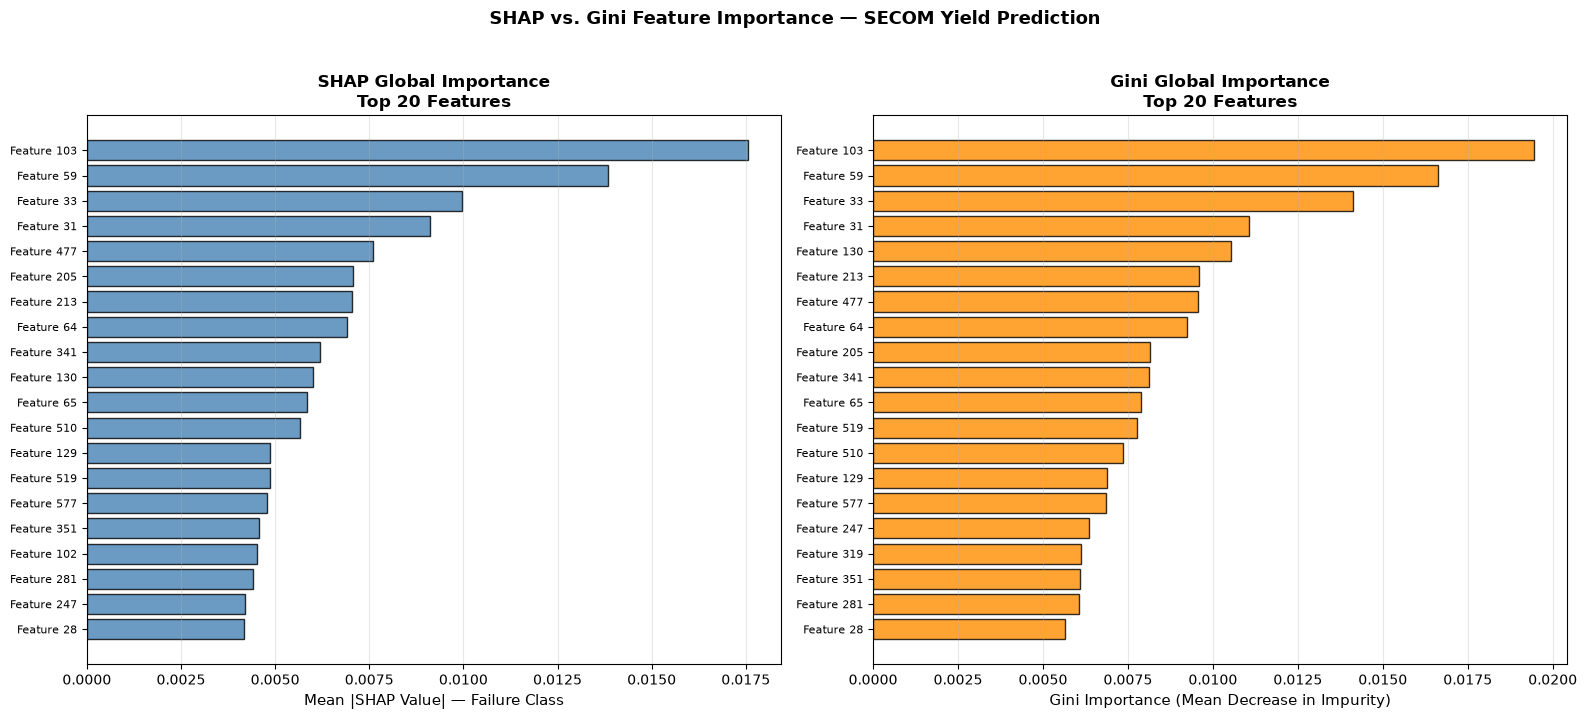


Top-10 overlap between SHAP and Gini: 10 features
Features in both: ['103', '130', '205', '213', '31', '33', '341', '477', '59', '64']
Features only in SHAP top-10: set()
Features only in Gini top-10: set()


In [7]:
# Mean absolute SHAP importance
shap_importance = pd.Series(
    np.abs(shap_fail).mean(axis=0),
    index=X_test_sc.columns
).sort_values(ascending=False)

# Compare with Gini importance from RF
gini_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# SHAP importance
top_shap = shap_importance.head(top_n)
axes[0].barh(range(top_n), top_shap.values[::-1],
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([f'Feature {int(i)}' 
                          for i in top_shap.index[::-1]], fontsize=8)
axes[0].set_xlabel('Mean |SHAP Value| — Failure Class', fontsize=11)
axes[0].set_title(f'SHAP Global Importance\nTop {top_n} Features', 
                   fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gini importance (top 20)
top_gini = gini_importance.head(top_n)
axes[1].barh(range(top_n), top_gini.values[::-1],
             color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([f'Feature {int(i)}' 
                          for i in top_gini.index[::-1]], fontsize=8)
axes[1].set_xlabel('Gini Importance (Mean Decrease in Impurity)', fontsize=11)
axes[1].set_title(f'Gini Global Importance\nTop {top_n} Features',
                   fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('SHAP vs. Gini Feature Importance — SECOM Yield Prediction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_vs_gini_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Check overlap between top-10 lists
top10_shap = set(shap_importance.head(10).index)
top10_gini = set(gini_importance.head(10).index)
overlap     = top10_shap & top10_gini
print(f"\nTop-10 overlap between SHAP and Gini: {len(overlap)} features")
print(f"Features in both: {sorted(overlap)}")
print(f"Features only in SHAP top-10: {top10_shap - top10_gini}")
print(f"Features only in Gini top-10: {top10_gini - top10_shap}")

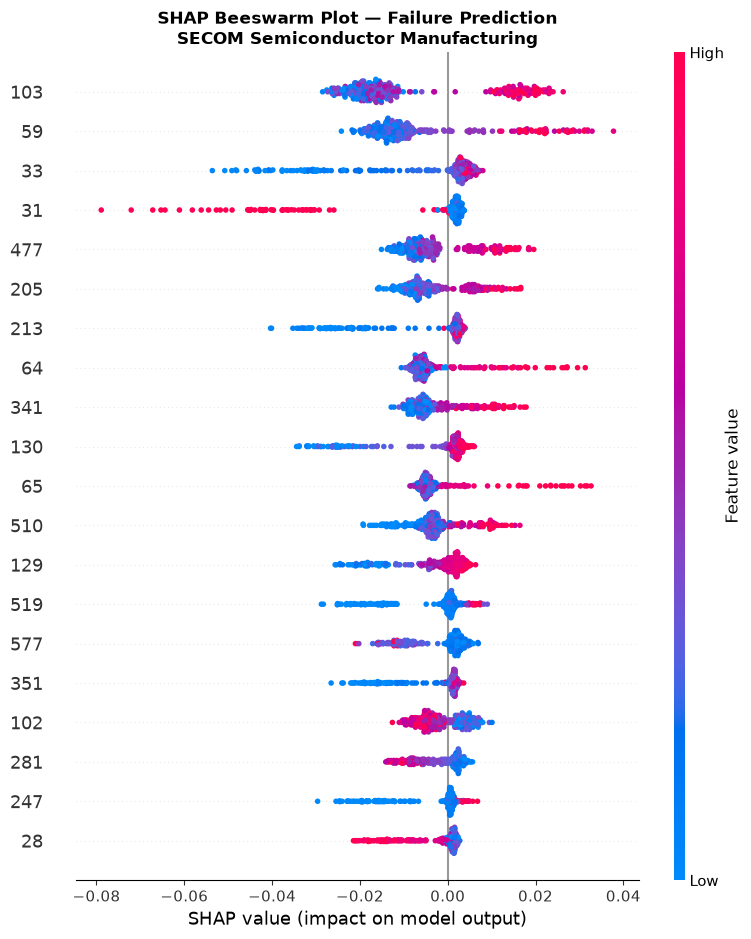

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_fail,
    X_test_sc,
    max_display=20,
    show=False,
    plot_type='dot'
)

plt.title('SHAP Beeswarm Plot — Failure Prediction\nSECOM Semiconductor Manufacturing',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Find a true positive: a wafer that actually failed and the model predicted correctly
y_prob_test = rf_model.predict_proba(X_test_sc)[:, 1]
y_pred_020  = (y_prob_test >= 0.20).astype(int)

true_positives  = np.where((y_pred_020 == 1) & (y_test == 1))[0]
false_negatives = np.where((y_pred_020 == 0) & (y_test == 1))[0]

print(f"True positives at threshold 0.20:  {len(true_positives)} wafers")
print(f"False negatives at threshold 0.20: {len(false_negatives)} wafers")

if len(true_positives) > 0:
    wafer_idx = true_positives[0]
    print(f"\nExplaining wafer index {wafer_idx}")
    print(f"  Actual label:     {'FAIL' if y_test.iloc[wafer_idx] == 1 else 'PASS'}")
    print(f"  Predicted prob:   {y_prob_test[wafer_idx]:.4f}")
    print(f"  Model prediction: {'FAIL' if y_pred_020[wafer_idx] == 1 else 'PASS'}")

True positives at threshold 0.20:  13 wafers
False negatives at threshold 0.20: 8 wafers

Explaining wafer index 60
  Actual label:     FAIL
  Predicted prob:   0.2801
  Model prediction: FAIL


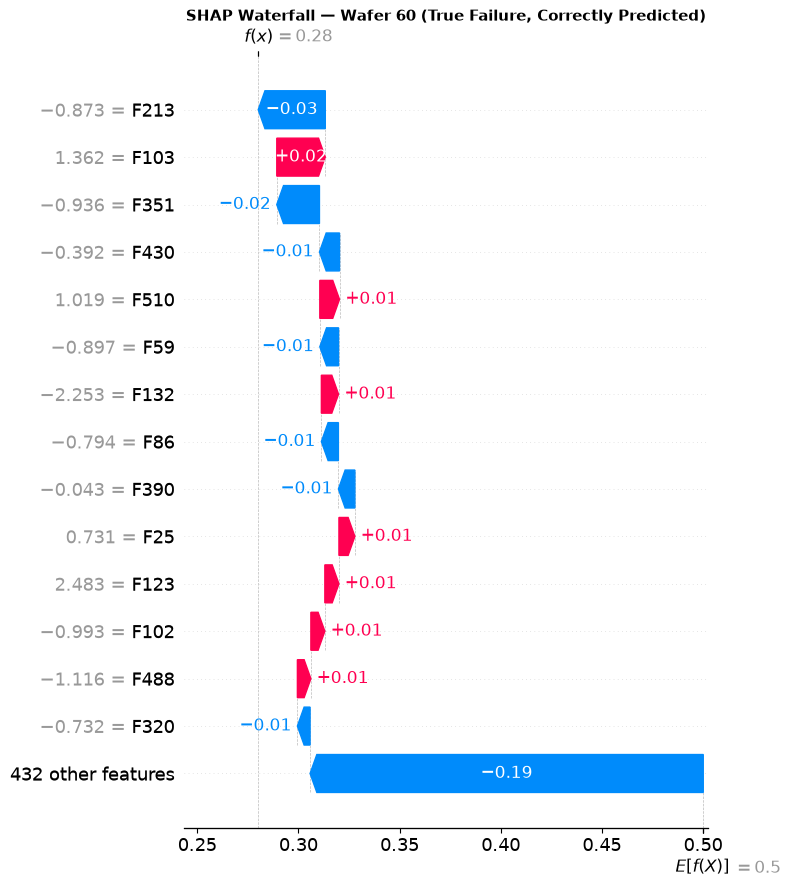

In [10]:
# Waterfall plot for one correctly predicted failure
shap_exp = shap.Explanation(
    values=shap_fail[wafer_idx],
    base_values=explainer.expected_value[1],
    data=X_test_sc.iloc[wafer_idx].values,
    feature_names=[f'F{i}' for i in X_test_sc.columns]
)

fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Wafer {wafer_idx} (True Failure, Correctly Predicted)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / f'shap_waterfall_TP_wafer{wafer_idx}.png', 
            dpi=150, bbox_inches='tight')
plt.show()

Explaining missed failure — wafer index 37
  Actual label:     FAIL
  Predicted prob:   0.1371
  Why missed: examining SHAP values...


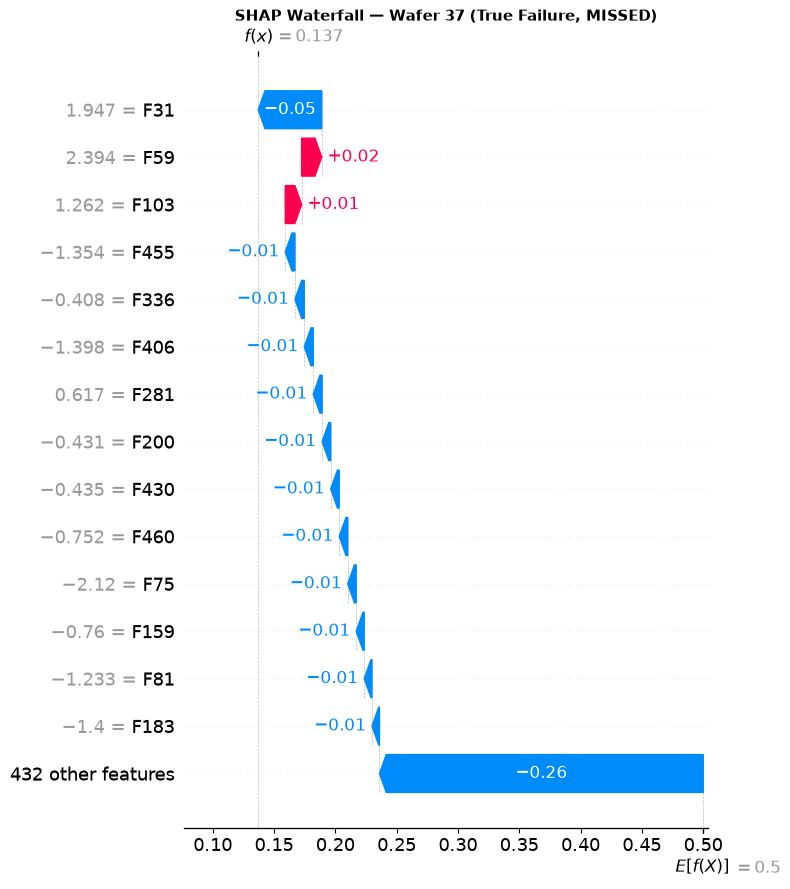

In [11]:
# Now explain a missed failure — false negative
if len(false_negatives) > 0:
    fn_idx = false_negatives[0]
    print(f"Explaining missed failure — wafer index {fn_idx}")
    print(f"  Actual label:     FAIL")
    print(f"  Predicted prob:   {y_prob_test[fn_idx]:.4f}")
    print(f"  Why missed: examining SHAP values...")
    
    shap_fn = shap.Explanation(
        values=shap_fail[fn_idx],
        base_values=explainer.expected_value[1],
        data=X_test_sc.iloc[fn_idx].values,
        feature_names=[f'F{i}' for i in X_test_sc.columns]
    )
    
    fig = plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_fn, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Wafer {fn_idx} (True Failure, MISSED)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / f'shap_waterfall_FN_wafer{fn_idx}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

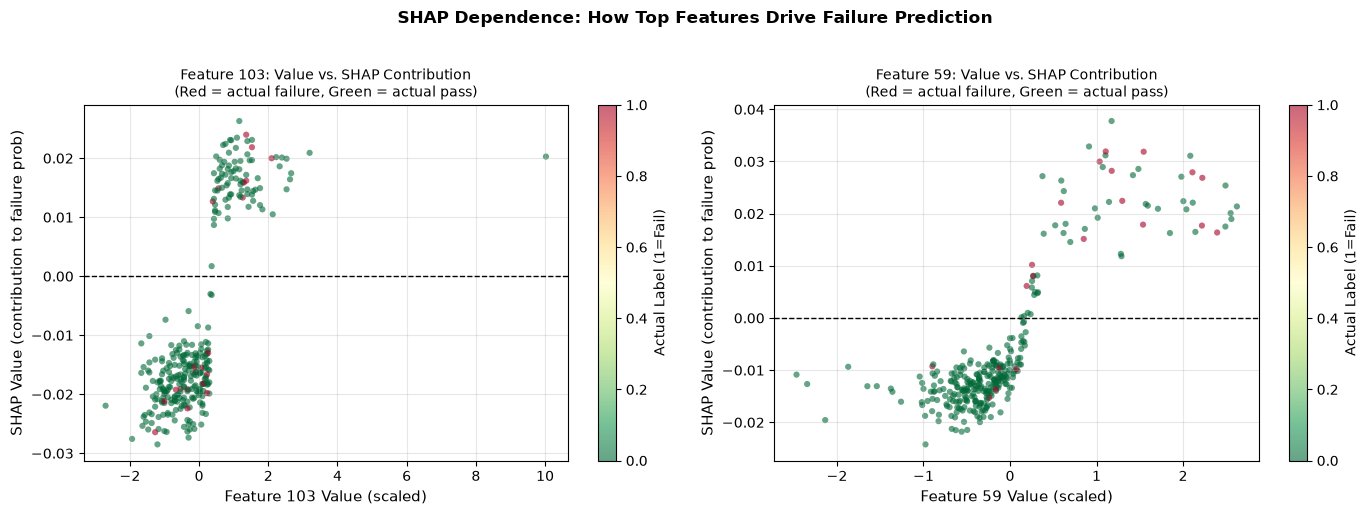

In [12]:
# Find top 2 SHAP-important features and visualize their interaction
top2_features = shap_importance.head(2).index.tolist()
f1_idx = list(X_test_sc.columns).index(top2_features[0])
f2_idx = list(X_test_sc.columns).index(top2_features[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat_idx, feat_name) in enumerate(zip([f1_idx, f2_idx], top2_features)):
    sc = axes[ax].scatter(
        X_test_sc.iloc[:, feat_idx],
        shap_fail[:, feat_idx],
        c=y_test,
        cmap='RdYlGn_r',
        alpha=0.6,
        edgecolors='none',
        s=20
    )
    axes[ax].axhline(y=0, color='black', linestyle='--', lw=1)
    axes[ax].set_xlabel(f'Feature {feat_name} Value (scaled)', fontsize=11)
    axes[ax].set_ylabel(f'SHAP Value (contribution to failure prob)', fontsize=11)
    axes[ax].set_title(f'Feature {feat_name}: Value vs. SHAP Contribution\n'
                        f'(Red = actual failure, Green = actual pass)', fontsize=10)
    plt.colorbar(sc, ax=axes[ax], label='Actual Label (1=Fail)')
    axes[ax].grid(alpha=0.3)

plt.suptitle('SHAP Dependence: How Top Features Drive Failure Prediction',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_dependence_top2.png', dpi=150, bbox_inches='tight')
plt.show()

=== SHAP Importance Concentration ===
Features needed for 50% of total importance: 82
Features needed for 80% of total importance: 237
Features needed for 95% of total importance: 369
Total features: 446


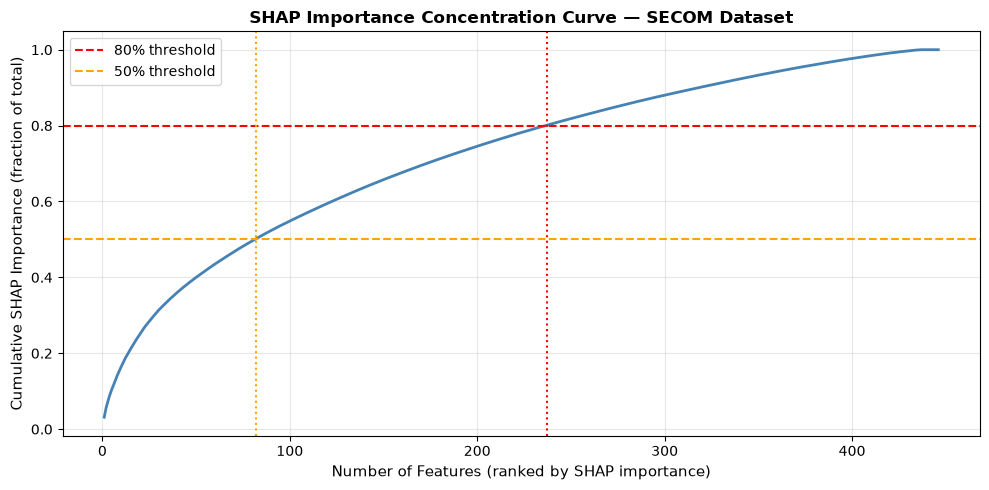

In [13]:
# How concentrated is SHAP importance?
total_shap_importance = shap_importance.sum()
cumulative_importance = shap_importance.cumsum() / total_shap_importance

features_for_50pct = (cumulative_importance < 0.50).sum() + 1
features_for_80pct = (cumulative_importance < 0.80).sum() + 1
features_for_95pct = (cumulative_importance < 0.95).sum() + 1

print("=== SHAP Importance Concentration ===")
print(f"Features needed for 50% of total importance: {features_for_50pct}")
print(f"Features needed for 80% of total importance: {features_for_80pct}")
print(f"Features needed for 95% of total importance: {features_for_95pct}")
print(f"Total features: {len(shap_importance)}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_importance)+1), 
        cumulative_importance.values, 'steelblue', lw=2)
ax.axhline(y=0.80, color='red', linestyle='--', lw=1.5, label='80% threshold')
ax.axhline(y=0.50, color='orange', linestyle='--', lw=1.5, label='50% threshold')
ax.axvline(x=features_for_80pct, color='red', linestyle=':', lw=1.5)
ax.axvline(x=features_for_50pct, color='orange', linestyle=':', lw=1.5)
ax.set_xlabel('Number of Features (ranked by SHAP importance)', fontsize=11)
ax.set_ylabel('Cumulative SHAP Importance (fraction of total)', fontsize=11)
ax.set_title('SHAP Importance Concentration Curve — SECOM Dataset',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_importance_concentration.png', dpi=150, bbox_inches='tight')
plt.show()